

```
Code for burner nozzle design
```



> 1. Code

In [3]:
"""
Closed-form design tool for a coaxial non-premixed (diffusion flame) burner.

This tool replaces the iterative gap-reduction procedure of the earlier
version with a closed-form sizing method.  The reasoning is as follows.

1. For fixed operating conditions (thermal power P, fuel, equivalence
   ratio phi) the mass flow rates mf and ma are fixed by combustion
   stoichiometry, mf / ma = 1 / AFR_actual.  Continuity then gives

       Af   = Qf / Vf
       Aann = Rm * Af * AFR_actual

   where Rm is the fuel-to-air mass flow rate ratio, (mf / Af) / (ma /
   Aann), i.e. the ratio of mass flux on the fuel side to mass flux on
   the air side.  So the geometry has exactly one degree of freedom, the
   fuel exit velocity Vf.  The problem is not underdetermined and no
   iteration is needed.  The earlier observation that "multiple feasible
   geometries exist" was the symptom of a missing closure condition.

2. The closure condition comes from flame stability.  A non-premixed jet
   flame lifts off when the exit velocity exceeds an onset value.  A
   Kalghatgi-type scaling estimates this onset as

       U_lo = 50 * SL_max * (rho_fuel / rho_air)**1.5

   The design velocity is set to U_lo / SF, where SF is a safety factor
   (default 1.3) that accounts for the scatter of the correlation and
   for the destabilizing effect of the coaxial air stream.

3. There is no lower velocity bound of the flashback type, because fuel
   and air first meet at the exit plane.  The old constraint Vf > 5 m/s
   is therefore removed.  Turndown is handled by verifying the design
   across the full power range instead of forcing a velocity floor.

4. Fuel ports are snapped to standard commercial tube sizes and the
   casing to standard pipe bores, choosing the nearest size that keeps
   the velocity at or below the design value and the mass flow rate
   ratio inside the specified band.

Usage:
    python burner_design_tool.py

Dependencies: none beyond the standard library.  matplotlib is optional
and only used for the nozzle profile figure; the run continues without
it if it is not installed.
"""

import math

# Property data (ideal gas at 298.15 K, 101.325 kPa)
P0 = 101325.0          # Pa
T0 = 298.15            # K
RU = 8314.462          # J/kmol K
M_AIR = 28.97          # kg/kmol
MU_AIR = 1.85e-5       # Pa s
G = 9.81               # m/s2
GAMMA_R_T = 346.0      # approximate speed of sound in the gases, m/s (for Mach check)

RHO_AIR = P0 * M_AIR / (RU * T0)
NU_AIR = MU_AIR / RHO_AIR

GAMMA_AIR = 1.400

FUELS = {
    "methane": dict(M=16.04, LHV=50.02e6, mu=1.10e-5, S_molar=9.52,
                    SL_max=0.39, T_ad=2226.0, gamma=1.31),
    "propane": dict(M=44.10, LHV=46.35e6, mu=8.10e-6, S_molar=23.8,
                    SL_max=0.45, T_ad=2267.0, gamma=1.13),
}
for f in FUELS.values():
    f["rho"] = P0 * f["M"] / (RU * T0)
    f["nu"] = f["mu"] / f["rho"]
    f["AFR"] = f["S_molar"] * M_AIR / f["M"]      # stoichiometric, mass basis

# Standard stock.  Tubes as (outer diameter, wall thickness) in mm.
STANDARD_TUBES = [(6.0, 1.0), (6.0, 1.25), (8.0, 1.0), (8.0, 1.2),
                  (10.0, 1.0), (10.0, 1.5), (12.0, 1.5)]
# Standard pipe bores (inner diameter) in mm: 1/2, 3/4, 1, 1-1/4 in Sch 40.
STANDARD_CASING_ID = [15.8, 20.9, 26.6, 35.1]




# fuel‑specific mass‑flux bounds
def mass_flux_bounds(fuel_name):
    """Return (lower, upper) mass‑flux‑ratio bounds for a given fuel,
    derived from the original velocity‑ratio criterion 1.0 <= Vf/Va <= 1.5.
    Rm = (rho_f / rho_a) * (Vf/Va)."""
    f = FUELS[fuel_name]
    ratio = f["rho"] / RHO_AIR
    return (ratio, 1.5 * ratio)


# Combustion calculations
def combustion(P_kW, fuel_name, phi=1.0):
    """Return mass and volumetric flow rates for one operating point."""
    f = FUELS[fuel_name]
    mf = P_kW * 1e3 / f["LHV"]
    ma = mf * f["AFR"] / phi
    return dict(fuel=fuel_name, P_kW=P_kW, phi=phi,
                mf=mf, ma=ma,
                Qf=mf / f["rho"], Qa=ma / RHO_AIR,
                AFR_actual=f["AFR"] / phi)


# Stability criterion (closure of the design problem)
def liftoff_velocity(fuel_name):
    """Kalghatgi-type estimate of the lift-off onset velocity, m/s.

    The coefficient carries a scatter of roughly a factor of 2, so the
    result must be used with a safety factor and confirmed by test.
    """
    f = FUELS[fuel_name]
    return 50.0 * f["SL_max"] * (f["rho"] / RHO_AIR) ** 1.5


# Closed-form sizing
def size_exact(P_design_kW, fuel_name, phi, Vf_design):
    """Exact (non-snapped) fuel-side area from continuity at the design
    point. Annulus sizing is not derived here: the casing bore is chosen
    directly from STANDARD_CASING_ID in snap_casing(), against the
    mass-flux-ratio bounds from mass_flux_bounds().
    """
    c = combustion(P_design_kW, fuel_name, phi)
    Af = c["Qf"] / Vf_design
    Di = math.sqrt(4.0 * Af / math.pi)
    return dict(Af=Af, Di=Di, flows=c)


def snap_fuel_tube(Af_required, vel_tolerance=0.02):
    """Standard tube with bore area closest to the requirement.

    Tubes whose bore area falls slightly short of the requirement are
    accepted as long as the resulting velocity excess stays within
    vel_tolerance (2 percent by default), which is negligible against
    the safety factor on the lift-off estimate.  Among the acceptable
    tubes, the one with the area closest to the requirement is chosen,
    so the actual velocity stays as close as possible to the design
    value.
    """
    best = None
    for od, wall in STANDARD_TUBES:
        bore = od - 2.0 * wall
        area = math.pi / 4.0 * (bore * 1e-3) ** 2
        if area >= Af_required / (1.0 + vel_tolerance):
            if best is None or abs(area - Af_required) < abs(best["Af"] - Af_required):
                best = dict(OD=od, wall=wall, ID=bore, Af=area)
    if best is None:
        raise ValueError("No standard tube is large enough; extend STANDARD_TUBES.")
    return best



def snap_casing(tips, flows_by_fuel, Vf_by_fuel, fuel_bands):
    """Select the smallest standard casing bore that gives a positive
    annulus for every fuel tip, and report the mass flow rate ratio Rm
    (fuel mass flux over air mass flux) each fuel sees at that bore.

    Rm carries the fuel density and the air-fuel ratio directly, so
    unlike the earlier velocity ratio (which is largely self-normalizing
    between fuels of similar density) it will not generally land every
    fuel inside the same band on one common casing when the fuels
    differ a lot in density, as methane and propane do here.  fuel_bands
    is a dict {fuel: (lower, upper)}.  A casing that puts every fuel
    inside its own band is chosen if one exists; otherwise the smallest
    feasible casing is used and the out‑of‑band condition is flagged
    later as a CHECK FAILED.
    """
    feasible = []
    for Dc in STANDARD_CASING_ID:
        detail = {}
        ok_area = True
        for fuel, tip in tips.items():
            Aann = math.pi / 4.0 * ((Dc * 1e-3) ** 2 - (tip["OD"] * 1e-3) ** 2)
            if Aann <= 0:
                ok_area = False
                break
            c = flows_by_fuel[fuel]
            Va = c["Qa"] / Aann
            Gf = c["mf"] / tip["Af"]           # fuel mass flux, kg/(s m2)
            Ga = c["ma"] / Aann                # air mass flux, kg/(s m2)
            Rm = Gf / Ga
            detail[fuel] = dict(Aann=Aann, Va=Va, Rm=Rm)
        if ok_area:
            # Check each fuel against its own band
            all_in_band = all(fuel_bands[fuel][0] <= detail[fuel]["Rm"] <= fuel_bands[fuel][1]
                              for fuel in tips)
            feasible.append((Dc, detail, all_in_band))
    if not feasible:
        raise ValueError("No standard casing gives a positive annulus for "
                         "every fuel tip; extend STANDARD_CASING_ID.")
    in_band = [c for c in feasible if c[2]]
    Dc, detail, _ = in_band[0] if in_band else feasible[0]
    return Dc, detail


# Verification across the operating envelope
def verify_point(P_kW, fuel_name, phi, tip, Dc_mm):
    """All derived quantities and checks at one operating point.

    Rm is the fuel-to-air mass flow rate ratio (mass flux ratio),
    (mf / Af) / (ma / Aann).  It is the design and verification
    parameter used in place of the earlier velocity ratio R = Vf / Va.
    """
    f = FUELS[fuel_name]
    c = combustion(P_kW, fuel_name, phi)
    Af = math.pi / 4.0 * (tip["ID"] * 1e-3) ** 2
    Aann = math.pi / 4.0 * ((Dc_mm * 1e-3) ** 2 - (tip["OD"] * 1e-3) ** 2)
    gap = (Dc_mm - tip["OD"]) / 2.0          # mm
    Dh = 2.0 * gap * 1e-3                    # m

    Vf = c["Qf"] / Af
    Va = c["Qa"] / Aann
    Gf = c["mf"] / Af
    Ga = c["ma"] / Aann
    Rm = Gf / Ga
    Re_f = Vf * tip["ID"] * 1e-3 / f["nu"]
    Re_a = Va * Dh / NU_AIR
    Fr = Vf ** 2 / (G * tip["ID"] * 1e-3)
    Mach = Vf / GAMMA_R_T
    L_roper = 1330.0 * c["Qf"] / math.log(1.0 + 1.0 / f["S_molar"])
    U_lo = liftoff_velocity(fuel_name)
    margin = U_lo / Vf
    dp_f = 0.5 * f["rho"] * Vf ** 2
    dp_a = 0.5 * RHO_AIR * Va ** 2

    return dict(fuel=fuel_name, P_kW=P_kW, Vf=Vf, Va=Va, Gf=Gf, Ga=Ga, Rm=Rm,
                Re_f=Re_f, Re_a=Re_a, Fr=Fr, Mach=Mach,
                gap_mm=gap, Dh_mm=Dh * 1e3,
                L_roper=L_roper, U_lo=U_lo, liftoff_margin=margin,
                dp_f=dp_f, dp_a=dp_a, flows=c)


# Nozzle profile (four independent fifth-order polynomial walls)
# Methodology follows the group's Curve_generator.m: each wall is its own
# fifth-order polynomial r(x), solved from six boundary conditions (radius
# and slope at the inlet, slope and curvature at the exit, plus an interior
# radius at the mid-length station that controls how front- or back-loaded
# the contraction is).  The four walls are solved independently, not scaled
# from one another.  Exit radii come from the calculated tube and casing
# geometry above; only the mid-length shape fractions are carried over from
# the MATLAB methodology, not any physical dimension.

CONTRACTION_AREA_RATIO = 42.25    # inlet-to-exit area ratio assumed for every wall
CONTRACTION_L_OVER_DC = 6.0     # contraction length as a multiple of the casing exit bore

# Shape control fractions, one per wall, following MATLAB's own convention:
# the wall radius at the mid-length station is a fraction of the INLET
# radius (y = frac * R_in), not a fraction of the inlet-to-exit span. The
# span-based re-parametrization used previously was introduced to guarantee
# monotonicity at small contraction ratios, but it was never re-derived
# from MATLAB's actual numbers once the ratio was fixed at 42.25 -- the
# fractions below (0.54/0.56/0.57 direct from the .m file, casing_outer
# lower from 0.59 to 0.575 only as far as needed for strict numerical
# monotonicity at every standard casing bore) are MATLAB's own Ai/Ac/Ao/Am
# mid-length targets, reproducing its shape as closely as possible.
WALL_MID_FRACTION = dict(fuel_inner=0.54, fuel_outer=0.56,
                         casing_inner=0.57, casing_outer=0.575)


def gaussian_solve(A, B):
    """Solve the square linear system A x = B by Gaussian elimination
    with partial pivoting.  Plain Python, no numpy dependency, since the
    system here is always the same small size (six boundary conditions
    for a fifth-order polynomial)."""
    n = len(B)
    M = [list(A[i]) + [B[i]] for i in range(n)]
    for col in range(n):
        pivot = max(range(col, n), key=lambda r: abs(M[r][col]))
        if abs(M[pivot][col]) < 1e-14:
            raise ValueError("Singular system in nozzle profile solve.")
        M[col], M[pivot] = M[pivot], M[col]
        for r in range(n):
            if r != col:
                factor = M[r][col] / M[col][col]
                for c_ in range(col, n + 1):
                    M[r][c_] -= factor * M[col][c_]
    return [M[i][n] / M[i][i] for i in range(n)]


def poly_eval(coeffs, x):
    """Evaluate c5 x^5 + c4 x^4 + ... + c0, coeffs = [c5, c4, c3, c2, c1, c0]."""
    c5, c4, c3, c2, c1, c0 = coeffs
    return c5 * x**5 + c4 * x**4 + c3 * x**3 + c2 * x**2 + c1 * x + c0


def solve_quintic_wall(R_in, R_exit, L_mm, mid_frac):
    """One nozzle wall as a fifth-order polynomial r(x), 0 <= x <= L_mm,
    solved from its own six boundary conditions, matching Curve_generator.m:

        r(0)    = R_in            inlet radius
        r'(0)   = 0               smooth (tangent) inlet
        r'(L)   = 0               smooth (tangent) exit
        r''(L)  = 0               no curvature break at the exit
        r(L)    = R_exit          exit radius, from calculated geometry
        r(L/2)  = mid_frac * R_in   interior shape control point, as a
                                    fraction of the INLET radius -- MATLAB's
                                    own convention (y = frac*Y), not a
                                    fraction of the inlet-to-exit span.
    """
    L_mid = 0.5 * L_mm
    A = [
        [0, 0, 0, 0, 0, 1],
        [5 * L_mm**4, 4 * L_mm**3, 3 * L_mm**2, 2 * L_mm, 1, 0],
        [20 * L_mm**3, 12 * L_mm**2, 6 * L_mm, 2, 0, 0],
        [0, 0, 0, 0, 1, 0],
        [L_mm**5, L_mm**4, L_mm**3, L_mm**2, L_mm, 1],
        [L_mid**5, L_mid**4, L_mid**3, L_mid**2, L_mid, 1],
    ]
    mid_value = mid_frac * R_in
    B = [R_in, 0.0, 0.0, 0.0, R_exit, mid_value]
    return gaussian_solve(A, B)


def nozzle_profile(tip, Dc_mm, n=200):
    """Four independent fifth-order polynomial wall profiles for the
    coaxial nozzle at one fuel tip's design point: fuel inner wall
    (fuel bore), fuel tube outer wall, casing inner wall (air bore) and
    casing outer wall.

    Exit radii are taken directly from the calculated burner geometry
    (tip and casing), so the contraction always ends exactly on the
    design dimensions.  Inlet (plenum-side) radii assume a contraction
    area ratio of CONTRACTION_AREA_RATIO on every wall, the same
    assumption the base report already used for the casing contraction.
    The contraction length scales with the casing exit bore rather than
    being a fixed number.
    """
    r_ratio = math.sqrt(CONTRACTION_AREA_RATIO)
    L_mm = CONTRACTION_L_OVER_DC * Dc_mm
    CASING_WALL = 1.45
    Dc_od = Dc_mm + 2*CASING_WALL

    exits = dict(
        fuel_inner=tip["ID"] / 2.0,
        fuel_outer=tip["OD"] / 2.0,
        casing_inner=Dc_mm / 2.0,
        casing_outer=Dc_od / 2.0,
    )

    walls = {}
    for name, R_exit in exits.items():
        R_in = r_ratio * R_exit
        coeffs = solve_quintic_wall(R_in, R_exit, L_mm, WALL_MID_FRACTION[name])
        xs = [L_mm * i / (n - 1) for i in range(n)]
        rs = [poly_eval(coeffs, x) for x in xs]
        walls[name] = dict(R_in=R_in, R_exit=R_exit, L_mm=L_mm,
                           coeffs=coeffs, x_mm=xs, r_mm=rs)
    return walls


def check_nozzle_profile(walls, tol=1e-9):
    """Sanity checks on the four-wall profile: the fuel tube and the
    casing must each keep positive wall thickness everywhere, and every
    wall must be continuously converging (no diverging section)."""
    problems = []
    n = len(walls["fuel_inner"]["x_mm"])

    if any(walls["fuel_outer"]["r_mm"][i] <= walls["fuel_inner"]["r_mm"][i]
           for i in range(n)):
        problems.append("Fuel tube wall thickness reaches zero or less "
                        "along the contraction.")
    if any(walls["casing_outer"]["r_mm"][i] <= walls["casing_inner"]["r_mm"][i]
           for i in range(n)):
        problems.append("Casing wall thickness reaches zero or less "
                        "along the contraction.")

    for name, w in walls.items():
        r = w["r_mm"]
        if any(r[i + 1] > r[i] + tol for i in range(len(r) - 1)):
            problems.append(f"{name}: profile is not continuously "
                            "converging (a diverging section was found).")
    return problems


def plot_nozzle_profile(walls, fuel_name, Dc_mm):
    """Optional figure of the four wall profiles, upper and lower
    branch, in the style of the group's MATLAB profile generator.
    Skipped quietly if matplotlib is not installed."""
    try:
        import matplotlib.pyplot as plt
    except ImportError:
        print("  matplotlib not installed; skipping the nozzle profile plot.")
        return None

    fig, ax = plt.subplots()
    for name, w in walls.items():
        x = w["x_mm"]
        r_pos = w["r_mm"]
        r_neg = [-v for v in r_pos]
        line, = ax.plot(x, r_pos, label=name)
        ax.plot(x, r_neg, color=line.get_color())
    ax.set_xlabel("axial distance (mm)")
    ax.set_ylabel("radius (mm)")
    ax.set_title(f"Coaxial nozzle profile, {fuel_name}, casing {Dc_mm:.1f} mm bore")
    ax.axis("equal")
    ax.legend()
    fname = f"nozzle_profile_{fuel_name}.png"
    fig.savefig(fname, dpi=150)
    plt.close(fig)
    print(f"  Nozzle profile plot saved to {fname}")
    return fname



def design(P_design_kW=5.0, P_min_kW=2.0, fuels=("methane", "propane"),
           phi=1.0, safety_factor=1.3):
    print("Coaxial non-premixed burner, closed-form design")
    print(f"Design point {P_design_kW} kW, turndown to {P_min_kW} kW, "
          f"phi = {phi}, SF on lift-off = {safety_factor}")
    print("_" * 72)

    # Step 1: design velocity from the stability criterion.  The binding
    # fuel is the one with the lowest lift-off onset (methane here).
    U_lo_min = min(liftoff_velocity(f) for f in fuels)
    binding = min(fuels, key=liftoff_velocity)
    Vf_design = U_lo_min / safety_factor
    print(f"Lift-off onset estimates: " +
          ", ".join(f"{f} {liftoff_velocity(f):.1f} m/s" for f in fuels))
    print(f"Binding fuel: {binding}.  Design fuel velocity "
          f"Vf = {U_lo_min:.1f} / {safety_factor} = {Vf_design:.2f} m/s")
    print("_" * 72)

    # Step 2: closed-form areas and snapping to standard tubes.
    tips, flows5, Vf_actual = {}, {}, {}
    for fuel in fuels:
        exact = size_exact(P_design_kW, fuel, phi, Vf_design)
        tip = snap_fuel_tube(exact["Af"])
        tips[fuel] = tip
        flows5[fuel] = exact["flows"]
        Vf_actual[fuel] = exact["flows"]["Qf"] / tip["Af"]
        print(f"{fuel}: required Af = {exact['Af']*1e6:.2f} mm2 "
              f"(Di = {exact['Di']*1e3:.2f} mm); selected tube "
              f"{tip['OD']:.1f} mm OD x {tip['wall']:.2f} mm wall, "
              f"bore {tip['ID']:.1f} mm, Af = {tip['Af']*1e6:.2f} mm2, "
              f"Vf = {Vf_actual[fuel]:.2f} m/s")

    # Step 3: one common casing for all tips.
    # Compute fuel-specific mass flux bounds
    fuel_bands = {f: mass_flux_bounds(f) for f in fuels}
    Dc, detail = snap_casing(tips, flows5, Vf_actual, fuel_bands)
    print(f"Common casing bore: {Dc} mm")
    for fuel, d in detail.items():
        lb, ub = fuel_bands[fuel]
        print(f"  {fuel}: Aann = {d['Aann']*1e6:.1f} mm2, "
              f"Va = {d['Va']:.2f} m/s, Rm = {d['Rm']:.2f} "
              f"(band {lb:.3f}–{ub:.3f})")
    print("_" * 72)

    # Step 4: verification across the envelope.
    header = (f"{'Case':<18}{'Vf':>7}{'Va':>7}{'Rm':>7}{'Re_f':>7}{'Re_a':>7}"
              f"{'Fr':>7}{'LO marg':>9}{'dp_f Pa':>9}{'dp_a Pa':>9}")
    print(header)
    results = []
    for fuel in fuels:
        for P in (P_min_kW, P_design_kW):
            r = verify_point(P, fuel, phi, tips[fuel], Dc)
            results.append(r)
            print(f"{fuel + ', ' + str(P) + ' kW':<18}"
                  f"{r['Vf']:>7.2f}{r['Va']:>7.2f}{r['Rm']:>7.2f}"
                  f"{r['Re_f']:>7.0f}{r['Re_a']:>7.0f}{r['Fr']:>7.0f}"
                  f"{r['liftoff_margin']:>9.2f}{r['dp_f']:>9.1f}{r['dp_a']:>9.1f}")
    print("_" * 72)

    # Step 5: checks with plain pass/fail reporting.
    problems = []
    for r in results:
        lb, ub = mass_flux_bounds(r["fuel"])
        if r["liftoff_margin"] < 1.0:
            problems.append(f"{r['fuel']} {r['P_kW']} kW exceeds the lift-off estimate.")
        if not (lb <= r["Rm"] <= ub):
            problems.append(f"{r['fuel']} {r['P_kW']} kW: Rm = {r['Rm']:.2f} "
                            f"outside the band ({lb:.3f}, {ub:.3f}).")
        if r["Mach"] > 0.3:
            problems.append(f"{r['fuel']} {r['P_kW']} kW: compressible flow.")
    if problems:
        for p in problems:
            print("CHECK FAILED:", p)
    else:
        print("All checks passed.  The lift-off margin at maximum fire must "
              "still be confirmed by test, because the onset correlation "
              "carries a scatter of about a factor of 2.")
    print("_" * 72)

    # Step 6: nozzle wall profiles (governing fuel only)
    governing_fuel = binding   # already defined above as the fuel with lowest liftoff
    walls = nozzle_profile(tips[governing_fuel], Dc)
    wall_problems = check_nozzle_profile(walls)

    # Print governing-fuel header
    print("_" * 72)
    print("GOVERNING NOZZLE DESIGN")
    print("_" * 72)
    print(f"\nGoverning fuel : {governing_fuel}")
    print("\nReason :")
    print("• Lowest lift-off velocity")
    print("• Governs the burner sizing")
    print("• Used as the governing nozzle geometry")
    print("\nThis nozzle geometry will be used for both methane and propane.")


    # Print the profile details exactly as before (but only once)
    print(f"Nozzle profile, {governing_fuel} tip, contraction length "
          f"{walls['casing_inner']['L_mm']:.1f} mm:")
    for name, w in walls.items():
        print(f"  {name:<13} inlet r = {w['R_in']:6.2f} mm  ->  "
              f"exit r = {w['R_exit']:6.2f} mm")
    if wall_problems:
        for p in wall_problems:
            print("  CHECK FAILED:", p)
    else:
        print("  Profile checks passed: converging throughout, "
              "positive wall thickness maintained.")
    plot_nozzle_profile(walls, governing_fuel, Dc)
    print("_" * 72)


    import csv

    export_map = {
        "InnerNozzle_InnerSurface.csv": "fuel_inner",
        "InnerNozzle_OuterSurface.csv": "fuel_outer",
        "OuterNozzle_InnerSurface.csv": "casing_inner",
        "OuterNozzle_OuterSurface.csv": "casing_outer",
    }

    for filename, wall_name in export_map.items():

        wall = walls[wall_name]

        with open(filename, "w", newline="") as csvfile:

            writer = csv.writer(csvfile)

            writer.writerow(["x_mm", "y_mm"])

            for x, y in zip(wall["x_mm"], wall["r_mm"]):
                writer.writerow([x, y])

        print(f"Saved {filename}")


    return dict(
    tips=tips,
    casing_ID_mm=Dc,
    results=results,
    profile=walls,
    governing_fuel=governing_fuel
)


# Acoustic forcing module (drivers in the 50 to 1000 Hz band)
def sound_speed(gas):
    """Speed of sound at 298.15 K, m/s.  gas is 'air' or a fuel name."""
    if gas == "air":
        return math.sqrt(GAMMA_AIR * (RU / M_AIR) * T0)
    f = FUELS[gas]
    return math.sqrt(f["gamma"] * (RU / f["M"]) * T0)


def tube_modes(L_m, c):
    """Longitudinal resonance bounds of a passage of length L_m.
    The true frequencies depend on the termination impedances, which
    are not known until the rig is built.  The quarter-wave (one end
    pressure release, one end rigid) and half-wave (both ends pressure
    release) values bound the first mode; measure the actual transfer
    function to locate it.
    """
    return dict(quarter=c / (4.0 * L_m), half=c / (2.0 * L_m))


def helmholtz_frequency(V_m3, A_m2, L_m, c):
    """Resonance of a forcing plenum of volume V feeding a passage of
    area A and effective length L (include about 10 percent end
    correction in L).  Coarse tuning knob for the driver response."""
    return (c / (2.0 * math.pi)) * math.sqrt(A_m2 / (V_m3 * L_m))


def allowable_amplitude(fuel_name, Vf_mean):
    """Nominal amplitude ratio limit from the peak-velocity criterion.
    Lift-off responds to the instantaneous velocity, so the forcing
    amplitude A (velocity fluctuation over mean) must satisfy
    Vf (1 + A) <= U_lo.  The returned value carries the full scatter of
    the onset correlation; cap the working amplitude below it and
    replace it with the measured forced lift-off boundary after
    commissioning.
    """
    return liftoff_velocity(fuel_name) / Vf_mean - 1.0


def frequency_landscape(fuel_name, tip, Dc_mm, P_kW, phi=1.0,
                        A_target=0.3, L_fuel_tube=0.20, L_air_passage=0.11):
    """Intrinsic frequencies relevant to forcing at one operating point."""
    r = verify_point(P_kW, fuel_name, phi, tip, Dc_mm)
    Di = tip["ID"] * 1e-3
    Dh = r["Dh_mm"] * 1e-3
    c_f = sound_speed(fuel_name)
    c_a = sound_speed("air")
    return dict(
        flicker_Hz=1.5 / math.sqrt(Dc_mm * 1e-3),
        ring_regime_upper_Hz=A_target * r["Vf"] / (4.0 * Di),
        fuel_preferred_Hz=(0.3 * r["Vf"] / Di, 0.5 * r["Vf"] / Di),
        air_preferred_Hz=(0.3 * r["Va"] / Dh, 0.5 * r["Va"] / Dh),
        fuel_tube_modes_Hz=tube_modes(L_fuel_tube, c_f),
        air_passage_modes_Hz=tube_modes(L_air_passage, c_a),
        point=r,
    )


def forced_design(P_design_kW=5.0, P_min_kW=2.0, fuels=("methane", "propane"),
                  phi=1.0, A_target=0.3,
                  dyn_margin=1.1, L_fuel_tube=0.20,
                  plenum_volumes_cm3=(50, 100, 250, 500, 1000)):
    """
    Sizing for acoustically forced operation.
    """
    print("Coaxial burner, forcing-ready configuration")
    print(f"Target amplitude ratio A = {A_target}, dynamic margin = {dyn_margin}, "
          f"band 50 to 1000 Hz")
    print("_" * 72)

    U_lo_min = min(liftoff_velocity(f) for f in fuels)
    binding = min(fuels, key=liftoff_velocity)
    Vf_design = U_lo_min / ((1.0 + A_target) * dyn_margin)
    print(f"Binding fuel {binding}: Vf = {U_lo_min:.1f} / "
          f"({1 + A_target:.2f} x {dyn_margin}) = {Vf_design:.2f} m/s")

    tips, flows5, Vf_actual = {}, {}, {}
    for fuel in fuels:
        exact = size_exact(P_design_kW, fuel, phi, Vf_design)
        tip = snap_fuel_tube(exact["Af"])
        tips[fuel] = tip
        flows5[fuel] = exact["flows"]
        Vf_actual[fuel] = exact["flows"]["Qf"] / tip["Af"]
        print(f"{fuel}: tube {tip['OD']:.1f} mm OD x {tip['wall']:.2f} mm wall, "
              f"bore {tip['ID']:.1f} mm, Vf = {Vf_actual[fuel]:.2f} m/s at "
              f"{P_design_kW} kW")

    fuel_bands = {f: mass_flux_bounds(f) for f in fuels}
    Dc, detail = snap_casing(tips, flows5, Vf_actual, fuel_bands)
    print(f"Common casing bore: {Dc} mm "
          + ", ".join(f"{f}: Rm = {d['Rm']:.2f} (band {fuel_bands[f][0]:.3f}–{fuel_bands[f][1]:.3f})"
                      for f, d in detail.items()))
    print("_" * 72)

    print(f"{'Case':<18}{'Vf':>7}{'Va':>7}{'Rm':>7}{'A_max':>8}  amplitude limit")
    for fuel in fuels:
        for P in (P_min_kW, P_design_kW):
            r = verify_point(P, fuel, phi, tips[fuel], Dc)
            A_max = allowable_amplitude(fuel, r["Vf"])
            note = ("binding, cap working amplitude below nominal"
                    if fuel == binding and P == P_design_kW else "unconstrained")
            print(f"{fuel + ', ' + str(P) + ' kW':<18}"
                  f"{r['Vf']:>7.2f}{r['Va']:>7.2f}{r['Rm']:>7.2f}{A_max:>8.2f}  {note}")
    print("_" * 72)

    # Frequency landscape and Helmholtz estimates (unchanged)
    print("Frequency landscape at the design point (Hz):")
    for fuel in fuels:
        fl = frequency_landscape(fuel, tips[fuel], Dc, P_design_kW, phi,
                                 A_target, L_fuel_tube)
        fp = fl["fuel_preferred_Hz"]
        ap = fl["air_preferred_Hz"]
        tm = fl["fuel_tube_modes_Hz"]
        am = fl["air_passage_modes_Hz"]
        print(f"{fuel}: flicker {fl['flicker_Hz']:.0f}; vortex ring regime below "
              f"{fl['ring_regime_upper_Hz']:.0f}; fuel jet preferred mode "
              f"{fp[0]:.0f} to {fp[1]:.0f}; annulus preferred mode "
              f"{ap[0]:.0f} to {ap[1]:.0f}; fuel tube first mode between "
              f"{tm['quarter']:.0f} and {tm['half']:.0f}; air passage first mode "
              f"between {am['quarter']:.0f} and {am['half']:.0f}")
    print("_" * 72)

    print("Forcing plenum Helmholtz frequencies (Hz) against plenum volume:")
    header = f"{'V (cm3)':<10}" + "".join(f"{v:>8}" for v in plenum_volumes_cm3)
    print(header)
    c_a = sound_speed("air")
    Aann_ref = math.pi / 4.0 * ((Dc * 1e-3) ** 2
                                - (tips[list(fuels)[0]]["OD"] * 1e-3) ** 2)
    row = f"{'air':<10}"
    for v in plenum_volumes_cm3:
        row += f"{helmholtz_frequency(v * 1e-6, Aann_ref, 0.11, c_a):>8.0f}"
    print(row)
    for fuel in fuels:
        c_f = sound_speed(fuel)
        row = f"{fuel:<10}"
        for v in plenum_volumes_cm3:
            row += (f"{helmholtz_frequency(v * 1e-6, tips[fuel]['Af'], L_fuel_tube, c_f):>8.0f}")
        print(row)
    print("These are coarse estimates; the measured cold-flow transfer "
          "function replaces them once the rig exists.  Fuel-side resonances "
          "shift by the ratio of sound speeds when the fuel is changed.")


    governing_fuel = binding
    walls = nozzle_profile(tips[governing_fuel], Dc)
    wall_problems = check_nozzle_profile(walls)

    return dict(
    tips=tips,
    casing_ID_mm=Dc,
    profile=walls,
    governing_fuel=governing_fuel
)


if __name__ == "__main__":
    design()
    print("_" * 72)
    forced_design()

Coaxial non-premixed burner, closed-form design
Design point 5.0 kW, turndown to 2.0 kW, phi = 1.0, SF on lift-off = 1.3
________________________________________________________________________
Lift-off onset estimates: methane 8.0 m/s, propane 42.3 m/s
Binding fuel: methane.  Design fuel velocity Vf = 8.0 / 1.3 = 6.18 m/s
________________________________________________________________________
methane: required Af = 24.67 mm2 (Di = 5.60 mm); selected tube 8.0 mm OD x 1.20 mm wall, bore 5.6 mm, Af = 24.63 mm2, Vf = 6.19 m/s
propane: required Af = 9.68 mm2 (Di = 3.51 mm); selected tube 6.0 mm OD x 1.25 mm wall, bore 3.5 mm, Af = 9.62 mm2, Vf = 6.22 m/s
Common casing bore: 20.9 mm
  methane: Aann = 292.8 mm2, Va = 4.96 m/s, Rm = 0.69 (band 0.554–0.831)
  propane: Aann = 314.8 mm2, Va = 4.52 m/s, Rm = 2.09 (band 1.522–2.283)
________________________________________________________________________
Case                   Vf     Va     Rm   Re_f   Re_a     Fr  LO marg  dp_f Pa  dp_a Pa
metha

> 2. For Nozzle profile, run the below sub-code

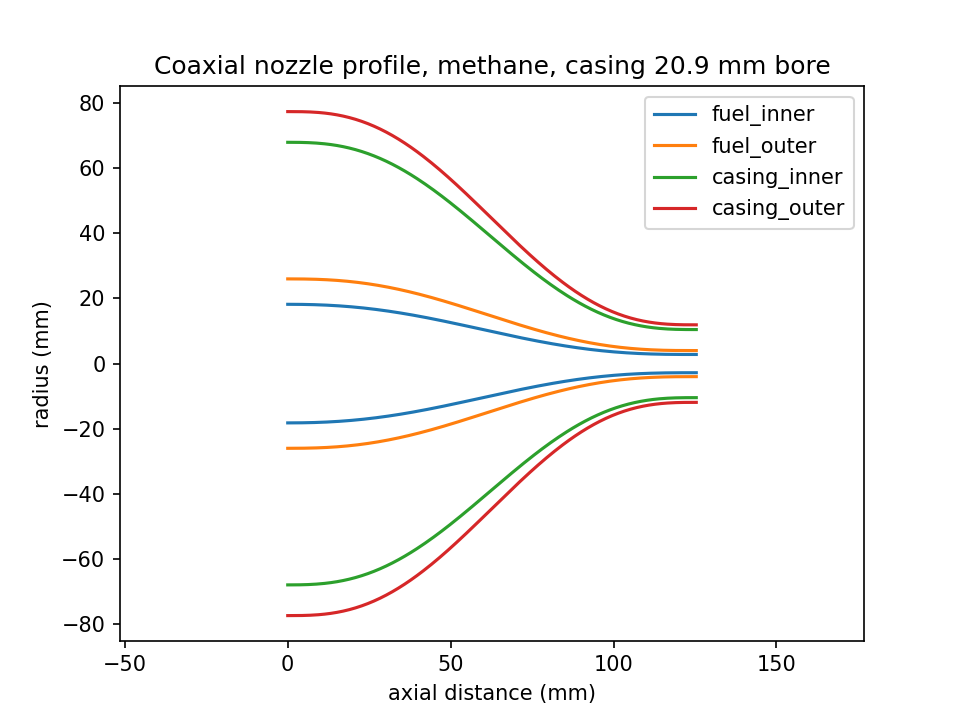

In [4]:
from IPython.display import Image
Image('nozzle_profile_methane.png')